In [2]:
import duckdb
import pandas as pd
from networks.inflammation_network import to_coral
from networks.inflammation_network import build_dataloaders
from networks.inflammation_network import InflammationModel

con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT 
                        p.row_id,
                        any_value(pid) as pid, 
                        any_value(value) as value,
                        any_value(fractions) as fractions,
                        any_value(boundaries) as boundaries,
                        any_value(albumin) as albumin,
                        any_value(antitrypsin) as antitrypsin,
                        any_value(orosomukoid) as orosomukoid,
                        any_value(haptoglobin) as haptoglobin,
                        any_value(crp) as crp,
                        any_value(igg) as igg,
                        any_value(iga) as iga,
                        any_value(igm) as igm,
                        list(c.comment_nr) as comment_nr,
                        any_value(age) as age,
                        any_value(sign) as sign,
                        any_value(set) as set,
                    FROM protein_data p
                    LEFT JOIN comment_precences c 
                        ON p.row_id = c.row_id
                    WHERE p.row_id IN (
                        SELECT row_id FROM comment_precences 
                        WHERE comment_nr BETWEEN 16 AND 27
                    )
                    GROUP BY p.row_id
                """).df()


con.close()

def get_inflammation_comment(comments):
    for i in range(16, 28):
        if i in comments:
            return i
    return None


df['inflammation_comment'] = df['comment_nr'].apply(get_inflammation_comment)
df = df[df['inflammation_comment'].notna()]


df['label'] = df['inflammation_comment'].apply(to_coral)
train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

print(df['label'].value_counts().sort_index())

train_dl, val_dl, test_dl = build_dataloaders(train_rows, val_rows, test_rows)
inflammation_model = InflammationModel()
#inflammation_model.retrain(train_dl,val_dl)

label
[0, 0, 0, 0, 0, 0, 0, 0]    78286
[1, 0, 0, 0, 0, 0, 0, 0]     3470
[1, 1, 0, 0, 0, 0, 0, 0]    10727
[1, 1, 1, 0, 0, 0, 0, 0]    47563
[1, 1, 1, 1, 0, 0, 0, 0]     7249
[1, 1, 1, 1, 1, 0, 0, 0]     4799
[1, 1, 1, 1, 1, 1, 0, 0]     1558
[1, 1, 1, 1, 1, 1, 1, 0]     5927
[1, 1, 1, 1, 1, 1, 1, 1]      235
Name: count, dtype: int64


MAE:          0.281
Exakt rätt:   80.3%
Inom ±1 grad: 93.2%
Inom ±2 grad: 98.4%
The bias is: -0.0001458650076529011
inflammation level: 0 | predicted amount within 1 unit: 3791 | true amount within 1 unit: 3762
inflammation level: 1 | predicted amount within 1 unit: 4030 | true amount within 1 unit: 174
inflammation level: 2 | predicted amount within 1 unit: 2404 | true amount within 1 unit: 456
inflammation level: 3 | predicted amount within 1 unit: 2828 | true amount within 1 unit: 2274
inflammation level: 4 | predicted amount within 1 unit: 968 | true amount within 1 unit: 326
inflammation level: 5 | predicted amount within 1 unit: 392 | true amount within 1 unit: 219
inflammation level: 6 | predicted amount within 1 unit: 350 | true amount within 1 unit: 55
inflammation level: 7 | predicted amount within 1 unit: 312 | true amount within 1 unit: 288
inflammation level: 8 | predicted amount within 1 unit: 49 | true amount within 1 unit: 8


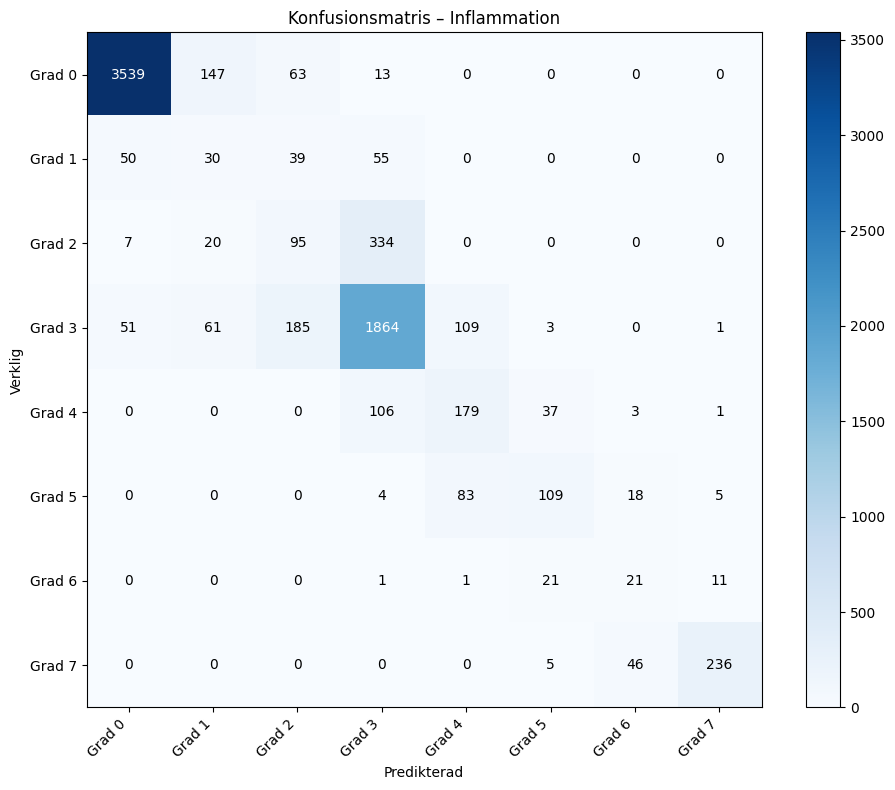

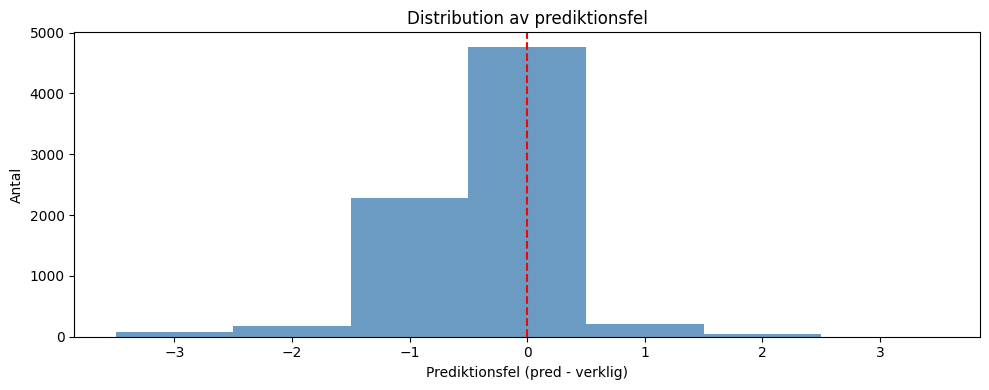

    inflammation_comment  severity_from_comment
0                     20                      0
1                     22                      3
2                     20                      0
3                     21                      2
4                     22                      3
5                     20                      0
6                     20                      0
7                     22                      3
8                     20                      0
9                     18                      3
10                    20                      0
11                    22                      3
12                    20                      0
13                    23                      4
14                    20                      0
15                    20                      0
16                    20                      0
17                    22                      3
18                    22                      3
19                    20                

,row_id,pid,value,fractions,boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm,comment_nr,age,sign,set,inflammation_comment,label,severity_from_comment
0,132371,73605251,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 4, 5, 6, ...","[65.0016164618203, 2.879003578903188, 8.288195...","[76, 93, 122, 132, 147, 174, 188, 202, 209, 22...",53.0,1.24,1.07,1.40,0.76,9.67,2.42,0.73,"[66, 4, 68, 20, 69, 97]",61.750000,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
1,132521,73700811,"[1, 2, 3, 3, 3, 3, 3, 3, 4, 4, 2, 1, 0, 0, 1, ...","[49.13888744108471, 7.984185014482178, 16.5223...","[82, 92, 123, 134, 142, 166, 194, 202, 214, 22...",29.0,2.39,1.51,3.35,7.00,9.08,1.30,0.80,"[66, 22, 9, 68, 8, 97, 69]",35.500000,nxu,train,22,"[1, 1, 1, 0, 0, 0, 0, 0]",3
2,132538,73708379,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 4, ...","[60.8665749656121, 3.561898211829436, 8.354195...","[79, 93, 122, 134, 149, 171, 190, 204, 215, 22...",44.0,1.34,0.62,0.82,0.86,11.30,1.89,2.58,"[20, 97, 70]",47.833333,nxu,val,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
3,132576,73717400,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[59.37942187184152, 4.840540498515028, 10.1988...","[78, 91, 119, 131, 147, 169, 188, 201, 212, 22...",44.0,1.62,1.37,1.49,10.00,11.90,2.34,0.70,"[21, 806, 90]",61.750000,nxu,train,21,"[1, 1, 0, 0, 0, 0, 0, 0]",2
4,132620,73723692,"[0, 2, 1, 2, 2, 2, 3, 4, 3, 5, 4, 5, 6, 6, 7, ...","[53.12667740203972, 4.473966720343532, 11.0721...","[79, 92, 118, 132, 146, 171, 186, 201, 212, 22...",36.0,1.65,1.33,2.69,19.00,14.20,4.74,0.48,"[70, 22, 110, 97]",73.750000,nxu,train,22,"[1, 1, 1, 0, 0, 0, 0, 0]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159809,131844,73365601,"[0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, ...","[57.149272421088995, 5.281747916576709, 15.990...","[81, 91, 121, 131, 140, 170, 190, 201, 208, 22...",35.0,1.69,1.19,3.20,7.90,5.19,1.39,0.48,"[97, 75, 22]",80.416667,mjo,train,22,"[1, 1, 1, 0, 0, 0, 0, 0]",3
159810,132233,73565827,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, ...","[52.337992276170176, 4.489574402818962, 15.694...","[81, 92, 125, 135, 144, 173, 197, 207, 215, 22...",39.0,1.82,0.81,4.71,1.60,11.50,2.52,1.39,"[66, 97, 18, 67]",69.916667,pad,train,18,"[1, 1, 1, 0, 0, 0, 0, 0]",3
159811,132239,73570639,"[0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, ...","[59.47467818310583, 3.550053462569258, 10.3175...","[78, 92, 117, 132, 144, 172, 190, 204, 212, 26...",43.0,1.08,1.11,1.91,4.20,11.90,2.34,1.23,"[22, 67, 200, 97, 66, 199]",59.666667,jhe,train,22,"[1, 1, 1, 0, 0, 0, 0, 0]",3
159812,132303,73599321,"[3, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 1, 2, 3, 4, ...","[49.69571746322077, 4.500445979970419, 10.4280...","[77, 91, 121, 133, 141, 174, 190, 203, 211, 22...",32.0,1.67,0.98,1.45,2.20,19.60,0.07,0.14,"[8, 20]",57.500000,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0


In [3]:
inflammation_model.evaluate_inflammation(val_dl)
from networks.inflammation_network import to_severity


df['severity_from_comment'] = df['inflammation_comment'].apply(to_severity)

print(df[['inflammation_comment','severity_from_comment']].head(20))
df

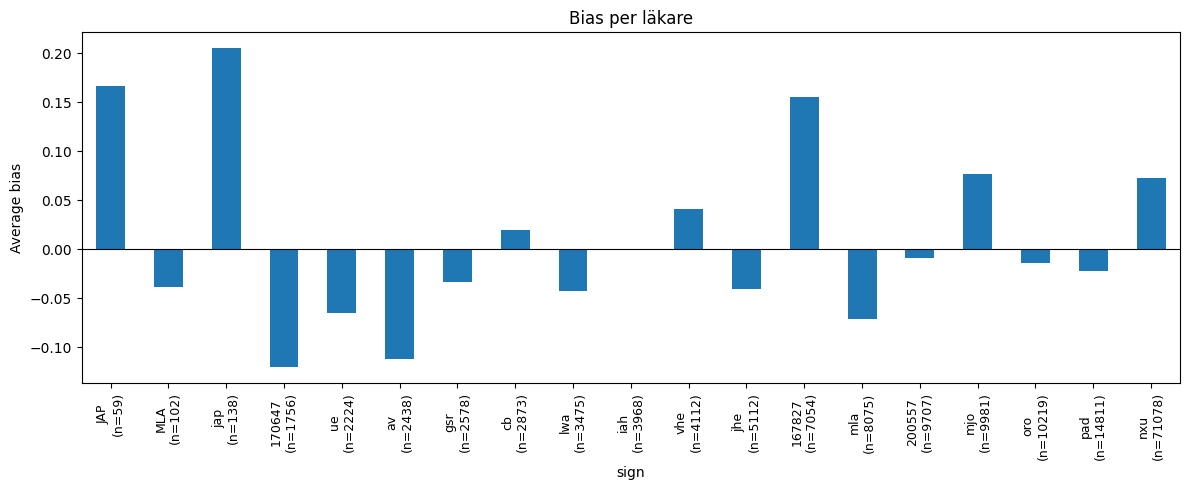

In [4]:

# Kör prediktioner på hela df
df = inflammation_model.predict(df)  # Lägger till df['inflammation']

# Lägg till true severity
from matplotlib import pyplot as plt

from networks.inflammation_network import to_severity

df['severity'] = df['inflammation_comment'].apply(to_severity)

# Analys
result = df[df['severity'].notna() & df['inflammation'].notna()].copy()
result['error'] = result['inflammation'] - result['severity']

summary = pd.DataFrame({
    'antal': result.groupby('sign').size(),
    'bias':  result.groupby('sign')['error'].mean()
}).sort_values('antal', ascending=False)

summary = summary[summary['antal'] > 50]
summary_sorted = summary.sort_values('antal')

labels = [f"{sign}\n(n={int(antal)})" for sign, antal in zip(summary_sorted.index, summary_sorted['antal'])]
summary_sorted['bias'].plot(kind='bar', figsize=(12, 5))
plt.xticks(range(len(labels)), labels, fontsize=9)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Average bias")
plt.title("Bias per läkare")
plt.tight_layout()
plt.show()